# 04 - Segmentacion RFM de Clientes

**Objetivo:** Clasificar la base de clientes usando el modelo RFM (Recency, Frequency, Monetary) para identificar segmentos accionables que informen la estrategia de retencion y reactivacion.

**Periodo de analisis:** Noviembre 2025 - Abril 2026  
**Base:** 3 500 ordenes - 1 404 clientes unicos  
**Referencia temporal:** 30 de abril de 2026

---

El modelo RFM asigna a cada cliente tres puntuaciones (1-5) segun:

| Dimension | Pregunta de negocio | Mejor score |
|---|---|---|
| **Recency (R)** | Dias desde la ultima compra | Pocos dias = 5 |
| **Frequency (F)** | Numero de ordenes en el periodo | Muchas = 5 |
| **Monetary (M)** | Ingreso total acumulado (USD) | Mayor gasto = 5 |

Los tres scores se combinan para asignar un segmento de negocio con acciones especificas de marketing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Librerias cargadas')
print(f'  pandas     {pd.__version__}')
print(f'  numpy      {np.__version__}')
print(f'  matplotlib {matplotlib.__version__}')

Librerias cargadas
  pandas     2.3.2
  numpy      2.3.3
  matplotlib 3.10.6


## 1. Carga y preparacion de datos

Se leen las ordenes limpias del pipeline de EDA (notebook 02). La fecha de referencia es el ultimo dia del periodo: **2026-04-30**.

In [2]:
df = pd.read_csv('data/processed/solvix_ordenes_clean.csv', parse_dates=['Fecha'])

FECHA_REF = pd.Timestamp('2026-04-30')

print(f'Ordenes cargadas : {len(df):,}')
print(f'Clientes unicos  : {df["ID_Cliente"].nunique():,}')
print(f'Rango de fechas  : {df["Fecha"].min().date()} al {df["Fecha"].max().date()}')
print(f'Fecha referencia : {FECHA_REF.date()}')
df.head(3)

Ordenes cargadas : 3,494
Clientes unicos  : 1,648
Rango de fechas  : 2025-11-01 al 2026-04-30
Fecha referencia : 2026-04-30


## 2. Calculo de metricas RFM brutas

Para cada cliente se calculan:
- **Recency:** dias transcurridos desde su ultima compra hasta la fecha de referencia
- **Frequency:** numero de ordenes colocadas en el periodo
- **Monetary:** ingreso total acumulado (USD)

In [3]:
rfm_raw = (
    df.groupby('ID_Cliente')
    .agg(
        ultima_compra  = ('Fecha', 'max'),
        frecuencia     = ('ID_Orden', 'count'),
        monetario      = ('Ingreso_Total', 'sum'),
    )
    .reset_index()
)

rfm_raw['recencia'] = (FECHA_REF - rfm_raw['ultima_compra']).dt.days

print(f'Clientes en tabla RFM: {len(rfm_raw):,}')
print()
print(rfm_raw[['ID_Cliente','recencia','frecuencia','monetario']].describe().round(1))

Clientes en tabla RFM: 1,648

       recencia  frecuencia  monetario
count    1648.0      1648.0     1648.0
mean       63.6         2.1      116.2
std        49.7         1.2       91.5
min        -1.0         1.0       22.1
25%        21.0         1.0       41.4
50%        52.0         2.0       90.1
75%       102.0         3.0      156.4
max       179.0         7.0      695.5


## 3. Scoring por quintiles (1-5)

Cada metrica se divide en 5 cuantiles iguales. El score 5 siempre indica el perfil mas valioso:
- **R**: score 5 = compro mas recientemente
- **F**: score 5 = mayor numero de ordenes
- **M**: score 5 = mayor gasto acumulado

El `rfm_score` combinado es la suma R+F+M (rango 3-15).

In [4]:
rfm = rfm_raw.copy()

rfm['R'] = pd.qcut(rfm['recencia'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frecuencia'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetario'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)

rfm['rfm_score'] = rfm['R'] + rfm['F'] + rfm['M']
rfm['rf_label']  = rfm['R'].astype(str) + rfm['F'].astype(str)

print('Distribucion de scores por dimension:')
for col in ['R','F','M']:
    print(f'  {col}: {dict(rfm[col].value_counts().sort_index())}')
print()
print(f'RFM score - min: {rfm["rfm_score"].min()}  max: {rfm["rfm_score"].max()}  media: {rfm["rfm_score"].mean():.1f}')
rfm[['ID_Cliente','R','F','M','rfm_score','recencia','frecuencia','monetario']].head(8)

Distribucion de scores por dimension:
  R: {1: np.int64(327), 2: np.int64(323), 3: np.int64(335), 4: np.int64(324), 5: np.int64(339)}
  F: {1: np.int64(330), 2: np.int64(329), 3: np.int64(330), 4: np.int64(329), 5: np.int64(330)}
  M: {1: np.int64(330), 2: np.int64(329), 3: np.int64(330), 4: np.int64(329), 5: np.int64(330)}

RFM score - min: 3  max: 15  media: 9.0


## 4. Asignacion de segmentos

Se aplica la matriz estandar de segmentos RFM basada en la combinacion R-F. Esta matriz es ampliamente usada en e-commerce para derivar acciones de marketing directas.

In [5]:
def asignar_segmento(r, f):
    if r >= 4 and f >= 4:      return 'Champions'
    elif r >= 3 and f >= 3:    return 'Leales'
    elif r >= 4 and f <= 2:    return 'Clientes Recientes'
    elif r == 3 and f <= 2:    return 'Prometedores'
    elif r == 2 and f >= 4:    return 'En Riesgo'
    elif r <= 2 and f >= 4:    return 'No Perder'
    elif r == 2 and f <= 2:    return 'Por Despertar'
    elif r <= 2 and f >= 2:    return 'Hibernando'
    else:                      return 'Perdidos'

rfm['segmento'] = rfm.apply(lambda x: asignar_segmento(x['R'], x['F']), axis=1)

resumen = (
    rfm.groupby('segmento')
    .agg(
        clientes        = ('ID_Cliente', 'count'),
        recencia_avg    = ('recencia', 'mean'),
        frecuencia_avg  = ('frecuencia', 'mean'),
        monetario_avg   = ('monetario', 'mean'),
        monetario_total = ('monetario', 'sum'),
    )
    .round(1)
    .sort_values('monetario_total', ascending=False)
    .reset_index()
)

resumen['pct_clientes'] = (resumen['clientes'] / resumen['clientes'].sum() * 100).round(1)
resumen['pct_ingreso']  = (resumen['monetario_total'] / resumen['monetario_total'].sum() * 100).round(1)

print(resumen.to_string(index=False))

          segmento  clientes  recencia_avg  frecuencia_avg  monetario_avg  monetario_total  pct_clientes  pct_ingreso
         Champions       371          16.2             3.4          189.0          70132.5          22.5         36.6
            Leales       358          39.3             2.5          134.6          48172.2          21.7         25.2
        Hibernando       231         124.3             1.5           81.7          18877.1          14.0          9.9
         En Riesgo       109          88.3             2.8          154.7          16858.8           6.6          8.8
Clientes Recientes       163          18.3             1.1           62.8          10231.5           9.9          5.3
      Prometedores       106          54.5             1.2           80.3           8516.4           6.4          4.4
     Por Despertar       134          91.6             1.1           62.8           8418.6           8.1          4.4
          Perdidos       139         147.3             1

## 5. Visualizacion de segmentos

### 5.1 Distribucion de clientes y valor por segmento

Grafico 1 guardado.


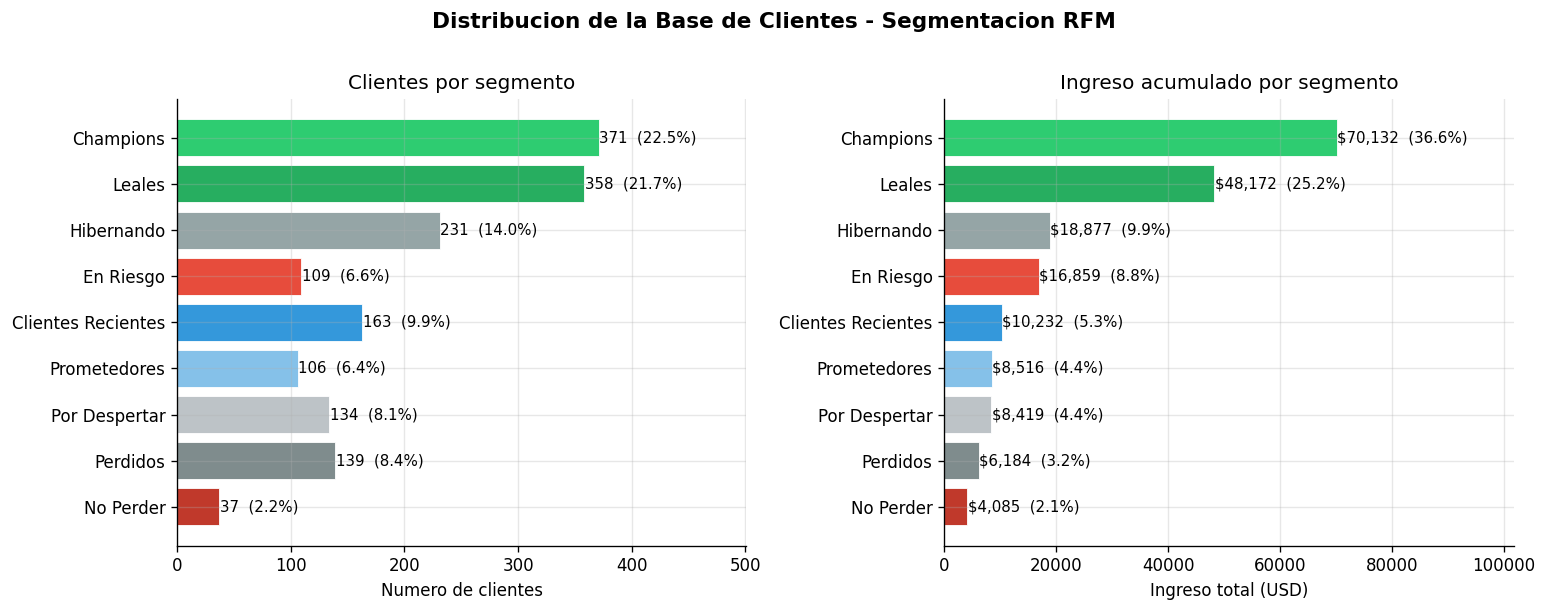

In [6]:
PALETA = {
    'Champions':          '#2ecc71',
    'Leales':             '#27ae60',
    'Clientes Recientes': '#3498db',
    'Prometedores':       '#85c1e9',
    'En Riesgo':          '#e74c3c',
    'No Perder':          '#c0392b',
    'Por Despertar':      '#bdc3c7',
    'Hibernando':         '#95a5a6',
    'Perdidos':           '#7f8c8d',
}

orden   = resumen['segmento'].tolist()
colores = [PALETA.get(s, '#aaa') for s in orden]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribucion de la Base de Clientes - Segmentacion RFM',
             fontsize=13, fontweight='bold', y=1.01)

ax1 = axes[0]
bars = ax1.barh(orden, resumen['clientes'], color=colores, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Numero de clientes')
ax1.set_title('Clientes por segmento')
ax1.invert_yaxis()
for bar, val, pct in zip(bars, resumen['clientes'], resumen['pct_clientes']):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val}  ({pct}%)', va='center', fontsize=9)
ax1.set_xlim(0, resumen['clientes'].max() * 1.35)

ax2 = axes[1]
bars2 = ax2.barh(orden, resumen['monetario_total'], color=colores, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Ingreso total (USD)')
ax2.set_title('Ingreso acumulado por segmento')
ax2.invert_yaxis()
for bar, val, pct in zip(bars2, resumen['monetario_total'], resumen['pct_ingreso']):
    ax2.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}  ({pct}%)', va='center', fontsize=9)
ax2.set_xlim(0, resumen['monetario_total'].max() * 1.45)

plt.tight_layout()
plt.savefig('data/processed/rfm_distribucion.png', bbox_inches='tight', dpi=130)
print('Grafico 1 guardado.')

### 5.2 Mapa de posicionamiento RFM (Recencia x Frecuencia)

Cada punto representa un cliente. La posicion en el plano refleja su comportamiento reciente y habitual de compra. El eje X esta invertido: los clientes mas activos (recientes) aparecen a la izquierda.

Grafico 2 guardado.


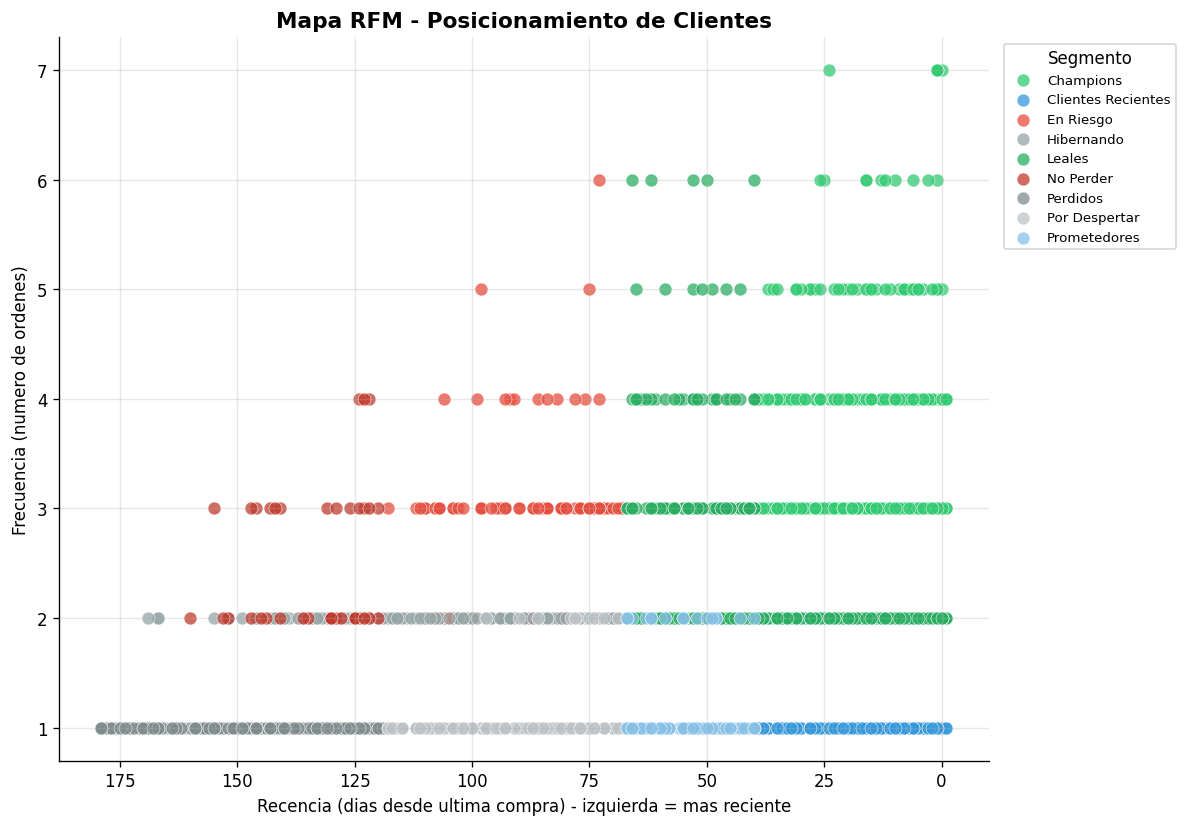

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

for seg, grupo in rfm.groupby('segmento'):
    ax.scatter(
        grupo['recencia'], grupo['frecuencia'],
        c=PALETA.get(seg, '#aaa'), label=seg,
        alpha=0.75, s=60, edgecolors='white', linewidths=0.4
    )

ax.set_xlabel('Recencia (dias desde ultima compra) - izquierda = mas reciente')
ax.set_ylabel('Frecuencia (numero de ordenes)')
ax.set_title('Mapa RFM - Posicionamiento de Clientes', fontsize=13, fontweight='bold')
ax.invert_xaxis()
ax.legend(title='Segmento', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('data/processed/rfm_mapa.png', bbox_inches='tight', dpi=130)
print('Grafico 2 guardado.')

### 5.3 Perfil de valor promedio por segmento

Grafico 3 guardado.


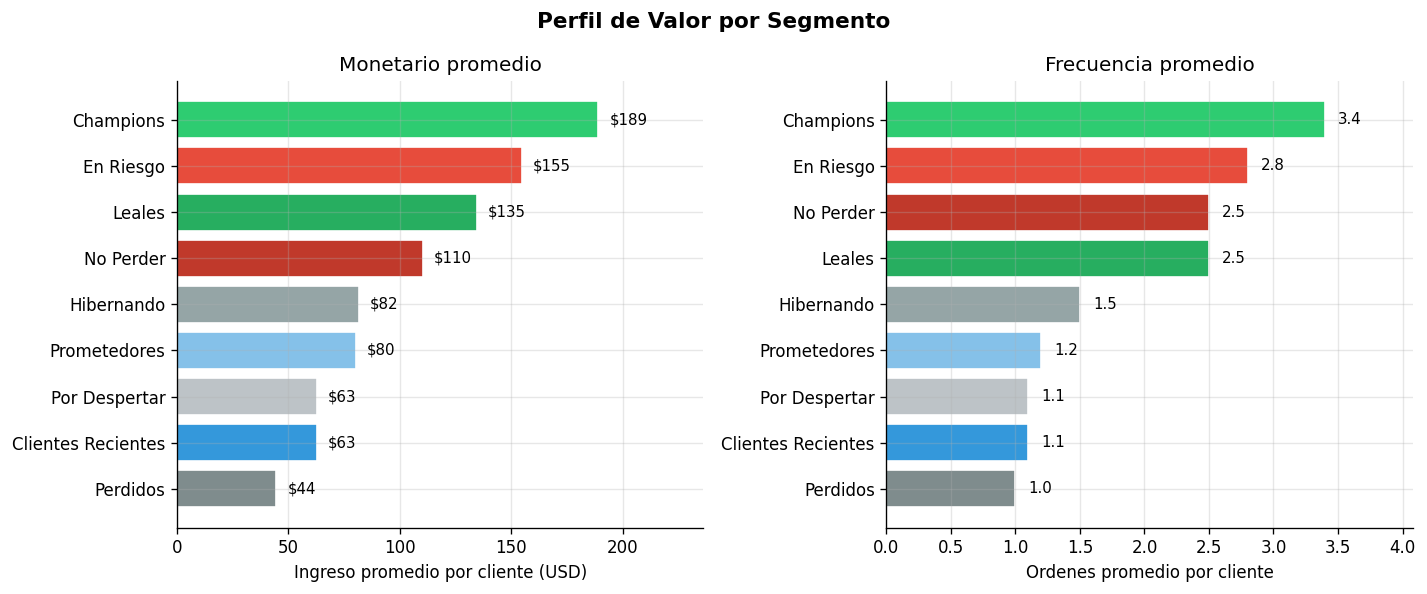

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Perfil de Valor por Segmento', fontsize=13, fontweight='bold')

orden_m  = resumen.sort_values('monetario_avg', ascending=True)['segmento'].tolist()
colores_m = [PALETA.get(s, '#aaa') for s in orden_m]
vals_m    = resumen.set_index('segmento').loc[orden_m, 'monetario_avg']

axes[0].barh(orden_m, vals_m, color=colores_m, edgecolor='white')
axes[0].set_xlabel('Ingreso promedio por cliente (USD)')
axes[0].set_title('Monetario promedio')
for i, v in enumerate(vals_m):
    axes[0].text(v + 5, i, f'${v:,.0f}', va='center', fontsize=9)
axes[0].set_xlim(0, vals_m.max() * 1.25)

orden_f   = resumen.sort_values('frecuencia_avg', ascending=True)['segmento'].tolist()
colores_f = [PALETA.get(s, '#aaa') for s in orden_f]
vals_f    = resumen.set_index('segmento').loc[orden_f, 'frecuencia_avg']

axes[1].barh(orden_f, vals_f, color=colores_f, edgecolor='white')
axes[1].set_xlabel('Ordenes promedio por cliente')
axes[1].set_title('Frecuencia promedio')
for i, v in enumerate(vals_f):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)
axes[1].set_xlim(0, vals_f.max() * 1.2)

plt.tight_layout()
plt.savefig('data/processed/rfm_valor.png', bbox_inches='tight', dpi=130)
print('Grafico 3 guardado.')

## 6. Hallazgos clave y recomendaciones

El analisis RFM revela la estructura real del negocio mas alla del revenue agregado.
Los segmentos de accion prioritaria son:

In [9]:
acciones = [
    ('Champions',          'Referral program + early access to new products.'),
    ('Leales',             'Loyalty discount on next order. Goal: move to Champions.'),
    ('En Riesgo',          'Urgent reactivation: personalized email with limited offer.'),
    ('No Perder',          'Direct outreach - high-value clients going inactive. VIP offer.'),
    ('Clientes Recientes', 'Onboarding: incentivize second purchase within 15 days.'),
    ('Prometedores',       'Increase frequency via cross-sell of related categories.'),
    ('Hibernando',         'Low-cost email/push campaign. Recoverable with right offer.'),
    ('Perdidos',           'No paid investment. Organic retargeting only.'),
]

print('RECOMENDACIONES POR SEGMENTO')
print('=' * 65)
for seg, accion in acciones:
    n = resumen[resumen['segmento'] == seg]['clientes'].values
    n_str = '(' + str(n[0]) + ' clientes)' if len(n) > 0 else ''
    print('  >> ' + seg + ' ' + n_str)
    print('     ' + accion)

top2 = resumen[resumen['segmento'].isin(['Champions','Leales'])]
n_top2   = top2['clientes'].sum()
pct_top2 = round(n_top2 / resumen['clientes'].sum() * 100, 1)
ing_top2 = top2['monetario_total'].sum()
pct_ing  = round(ing_top2 / resumen['monetario_total'].sum() * 100, 1)

print()
print('=' * 65)
print('Champions + Leales: ' + str(n_top2) + ' clientes (' + str(pct_top2) + '%) '
      'generan $' + '{:,.0f}'.format(ing_top2) + ' (' + str(pct_ing) + '% del ingreso total)')

RECOMENDACIONES POR SEGMENTO
  >> Champions (371 clientes)
     Referral program + early access to new products.
  >> Leales (358 clientes)
     Loyalty discount on next order. Goal: move to Champions.
  >> En Riesgo (109 clientes)
     Urgent reactivation: personalized email with limited offer.
  >> No Perder (37 clientes)
     Direct outreach - high-value clients going inactive. VIP offer.
  >> Clientes Recientes (163 clientes)
     Onboarding: incentivize second purchase within 15 days.
  >> Prometedores (106 clientes)
     Increase frequency via cross-sell of related categories.
  >> Hibernando (231 clientes)
     Low-cost email/push campaign. Recoverable with right offer.
  >> Perdidos (139 clientes)
     No paid investment. Organic retargeting only.

Champions + Leales: 729 clientes (44.2%) generan $118,305 (61.8% del ingreso total)


## 7. Exportar resultados para Power BI

Se exportan dos archivos:
- `rfm_clientes.csv` - tabla cliente-nivel con scores y segmento (pagina Clientes del dashboard)
- `rfm_resumen_segmentos.csv` - metricas agregadas por segmento

In [10]:
export = rfm[[
    'ID_Cliente','R','F','M','rfm_score','segmento',
    'recencia','frecuencia','monetario','ultima_compra'
]].sort_values('rfm_score', ascending=False)

export.to_csv('data/processed/rfm_clientes.csv', index=False)
print(f'rfm_clientes.csv exportado - {len(export):,} filas')

resumen.to_csv('data/processed/rfm_resumen_segmentos.csv', index=False)
print(f'rfm_resumen_segmentos.csv exportado - {len(resumen)} segmentos')

print()
print('Vista previa rfm_clientes.csv:')
export.head(5)

rfm_clientes.csv exportado - 1,648 filas
rfm_resumen_segmentos.csv exportado - 9 segmentos

Vista previa rfm_clientes.csv:
